# 03b. Logistic Regression — **PCA-Reduced Features**

**Objective:** Train the same Logistic Regression baseline as in `lr_baseline_model.ipynb` but on the PCA-reduced data from `03_processed_pca/` (produced by `02_preprocessing_pca.ipynb`).

**Key differences from the standard LR baseline:**
- Features are `PC1…PCk` (orthogonal, already standardised) — multicollinearity is eliminated by construction.
- Coefficient interpretation is in **PC space**; an additional back-projection step recovers approximate original-feature importance.
- `pca.pkl` is loaded for the back-projection.

**Key metric:** ROC-AUC — $AUC = P(\text{score}(\text{pos}) > \text{score}(\text{neg}))$

**Two training sets compared:**
- `X_train` / `y_train` — PCA-reduced, original imbalanced (~8% default rate)
- `X_train_smote` / `y_train_smote` — PCA-reduced + SMOTE-resampled (50/50 balance)

**Splits:** 70% train / 15% val / 15% test, stratified on TARGET (same split as notebook 02b).

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")
print(f"numpy {np.__version__}  |  pandas {pd.__version__}")

Libraries imported successfully.
numpy 2.0.2  |  pandas 2.2.2


## 1. Load PCA-Processed Data

Load splits from `03_processed_pca/` (produced by `02_preprocessing_pca.ipynb`).
Also load `pca.pkl` and the raw feature names for back-projection in Section 8.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca"

# --- Load all splits ---
X_train       = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_train_smote = pd.read_csv(f"{DATA_DIR}/X_train_smote.csv")
X_val         = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test        = pd.read_csv(f"{DATA_DIR}/X_test.csv")

y_train       = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_train_smote = pd.read_csv(f"{DATA_DIR}/y_train_smote.csv").squeeze()
y_val         = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze()
y_test        = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

# PC feature names (PC1, PC2, …)
pca_feature_names = pd.read_csv(f"{DATA_DIR}/feature_names.csv", header=None).squeeze().tolist()

# Original feature names (for back-projection in Section 8)
raw_feature_names = pd.read_csv(f"{DATA_DIR}/feature_names_raw.csv", header=None).squeeze().tolist()

# Fitted PCA object
pca = joblib.load(f"{DATA_DIR}/pca.pkl")

print("=== Shapes ===")
print(f"X_train       : {X_train.shape}")
print(f"X_train_smote : {X_train_smote.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test        : {X_test.shape}")
print(f"\n=== Target distribution ===")
print(f"Train (original) default rate : {y_train.mean():.4f}")
print(f"Train (SMOTE)    default rate : {y_train_smote.mean():.4f}")
print(f"Val              default rate : {y_val.mean():.4f}")
print(f"Test             default rate : {y_test.mean():.4f}")
print(f"\nPCA components (features): {len(pca_feature_names)}")
print(f"Original features:          {len(raw_feature_names)}")
print(f"Variance retained by PCA:   {pca.explained_variance_ratio_.sum()*100:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Shapes ===
X_train       : (215253, 49)
X_train_smote : (395752, 49)
X_val         : (46126, 49)
X_test        : (46126, 49)

=== Target distribution ===
Train (original) default rate : 0.0807
Train (SMOTE)    default rate : 0.5000
Val              default rate : 0.0807
Test             default rate : 0.0807

PCA components (features): 49
Original features:          113
Variance retained by PCA:   95.11%


## 2. Quick Sanity Checks

In [3]:
nan_counts = {
    "X_train"      : X_train.isna().sum().sum(),
    "X_train_smote": X_train_smote.isna().sum().sum(),
    "X_val"        : X_val.isna().sum().sum(),
    "X_test"       : X_test.isna().sum().sum(),
}
print("NaN counts per split:")
for k, v in nan_counts.items():
    status = "✓ clean" if v == 0 else f"⚠ {v} NaNs"
    print(f"  {k:20s}: {status}")

# PCA outputs are already zero-mean (by construction); confirm
print(f"\nX_train mean across PCs (should be ~0):  {X_train.values.mean():.6f}")
print(f"X_train std  across PCs (should be ~1):  {X_train.values.std():.4f}")

print("\nSample of X_train (PC space):")
X_train.head(3)

NaN counts per split:
  X_train             : ✓ clean
  X_train_smote       : ✓ clean
  X_val               : ✓ clean
  X_test              : ✓ clean

X_train mean across PCs (should be ~0):  -0.000000
X_train std  across PCs (should be ~1):  1.0226

Sample of X_train (PC space):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49
0,-0.137434,2.403125,0.815299,-0.902954,0.424146,0.092219,0.537007,1.482305,1.180162,1.450219,...,-0.611962,0.166887,-0.021164,0.500906,0.168063,0.376905,0.595379,0.392386,-0.351782,0.022532
1,-2.696143,-4.549472,-0.297896,-1.102067,2.043447,1.274637,-0.135806,-0.235456,0.352257,-0.065425,...,0.030130,0.057781,0.158133,-0.185214,-0.434926,-0.621957,0.329404,-0.228856,-0.029322,-0.147785
2,-1.899812,0.161899,0.538950,-1.423748,-0.334657,-1.203134,0.558639,0.654744,-1.112216,0.417956,...,-0.275450,-0.714396,-1.099628,-0.043447,0.220884,0.398107,0.208577,0.494471,-0.304429,0.020717


## 3. Helper Functions

Identical to the standard LR baseline — centralised so both training strategies are compared identically.

In [4]:
def evaluate_model(model, X, y, split_name="Val", threshold=0.5):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y, y_prob)
    pr_auc  = average_precision_score(y, y_prob)

    print(f"\n{'='*55}")
    print(f"  {split_name} — threshold = {threshold}")
    print(f"{'='*55}")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['No Default (0)', 'Default (1)'])}")

    return {"split": split_name, "roc_auc": roc_auc, "pr_auc": pr_auc}


def plot_evaluation(model, X_val, y_val, X_test, y_test, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Evaluation Plots", fontsize=14, fontweight='bold')

    # Confusion matrix (val at 0.5)
    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (y_prob_val >= 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred_val)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Confusion Matrix (Val, threshold=0.5)")

    # ROC curve
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    # Precision-Recall curve
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        prec, rec, _ = precision_recall_curve(y, y_prob)
        ap = average_precision_score(y, y_prob)
        axes[2].plot(rec, prec, label=f"{label} (AP={ap:.4f})")
    baseline_rate = y_val.mean()
    axes[2].axhline(baseline_rate, color='k', linestyle='--', linewidth=0.8,
                    label=f"Random baseline ({baseline_rate:.3f})")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 4. Train Model — Original Training Set (PCA)

Logistic Regression with `class_weight='balanced'`. Because PCA produces orthogonal features,
multicollinearity is eliminated — L2 regularisation with `C=1.0` is a fair starting point
(we can tune if needed). `lbfgs` converges faster on the smaller PCA feature set.

In [5]:
lr_base = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
)

print("Training LR (class_weight='balanced') on PCA-reduced training set...")
lr_base.fit(X_train, y_train)
print(f"  Converged in {lr_base.n_iter_[0]} iterations.")
print(f"  Number of features (PCs): {X_train.shape[1]}")

Training LR (class_weight='balanced') on PCA-reduced training set...
  Converged in 16 iterations.
  Number of features (PCs): 49



  Val  (original train, PCA) — threshold = 0.5
  ROC-AUC : 0.7453
  PR-AUC  : 0.2233

                precision    recall  f1-score   support

No Default (0)       0.96      0.68      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.68     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.90      0.68      0.76     46126


  Test (original train, PCA) — threshold = 0.5
  ROC-AUC : 0.7481
  PR-AUC  : 0.2316

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.68      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.90      0.69      0.76     46126



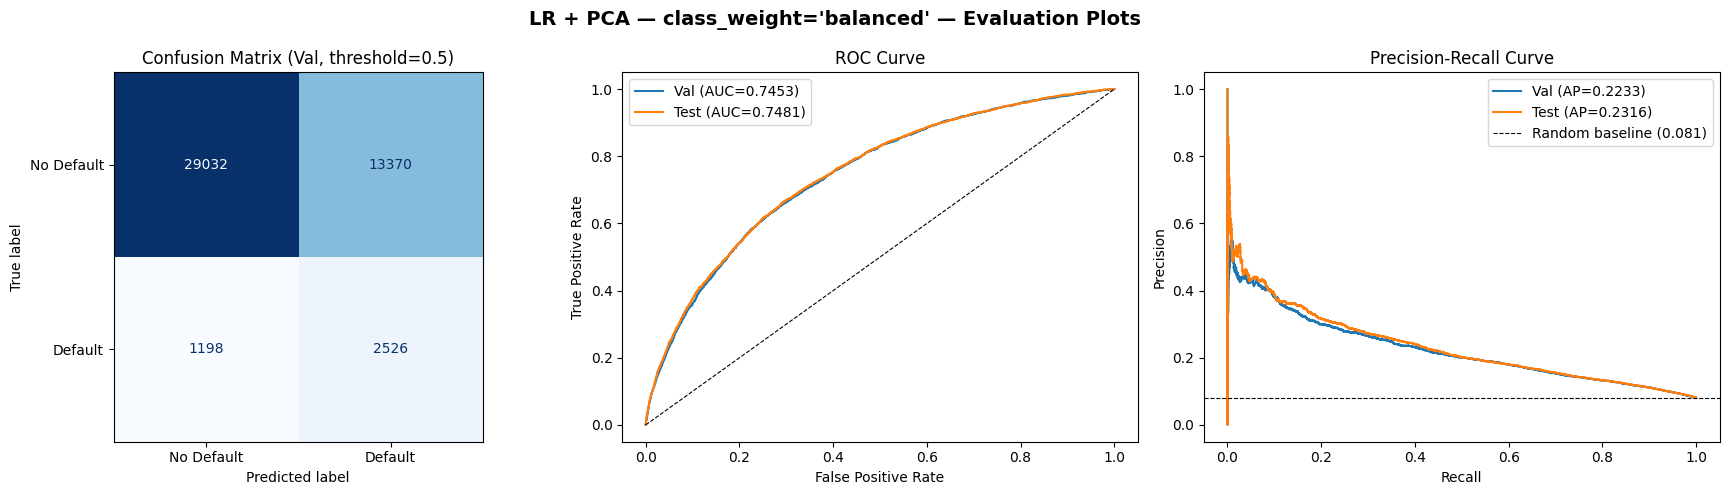

In [6]:
results_base_val  = evaluate_model(lr_base, X_val,  y_val,  split_name="Val  (original train, PCA)")
results_base_test = evaluate_model(lr_base, X_test, y_test, split_name="Test (original train, PCA)")

plot_evaluation(lr_base, X_val, y_val, X_test, y_test,
                title_prefix="LR + PCA — class_weight='balanced'")

## 5. Train Model — SMOTE Training Set (PCA)

SMOTE was applied in PCA space in notebook 02b, so synthetic samples are already in the reduced
orthogonal representation. No `class_weight` needed here since SMOTE already balanced the classes.

Training LR (SMOTE) on PCA-reduced training set...
  Converged in 17 iterations.

  Val  (SMOTE train, PCA) — threshold = 0.5
  ROC-AUC : 0.7409
  PR-AUC  : 0.2238

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.66      0.25      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.89      0.69      0.76     46126


  Test (SMOTE train, PCA) — threshold = 0.5
  ROC-AUC : 0.7433
  PR-AUC  : 0.2270

                precision    recall  f1-score   support

No Default (0)       0.96      0.69      0.80     42402
   Default (1)       0.16      0.67      0.26      3724

      accuracy                           0.69     46126
     macro avg       0.56      0.68      0.53     46126
  weighted avg       0.89      0.69      0.76     46126



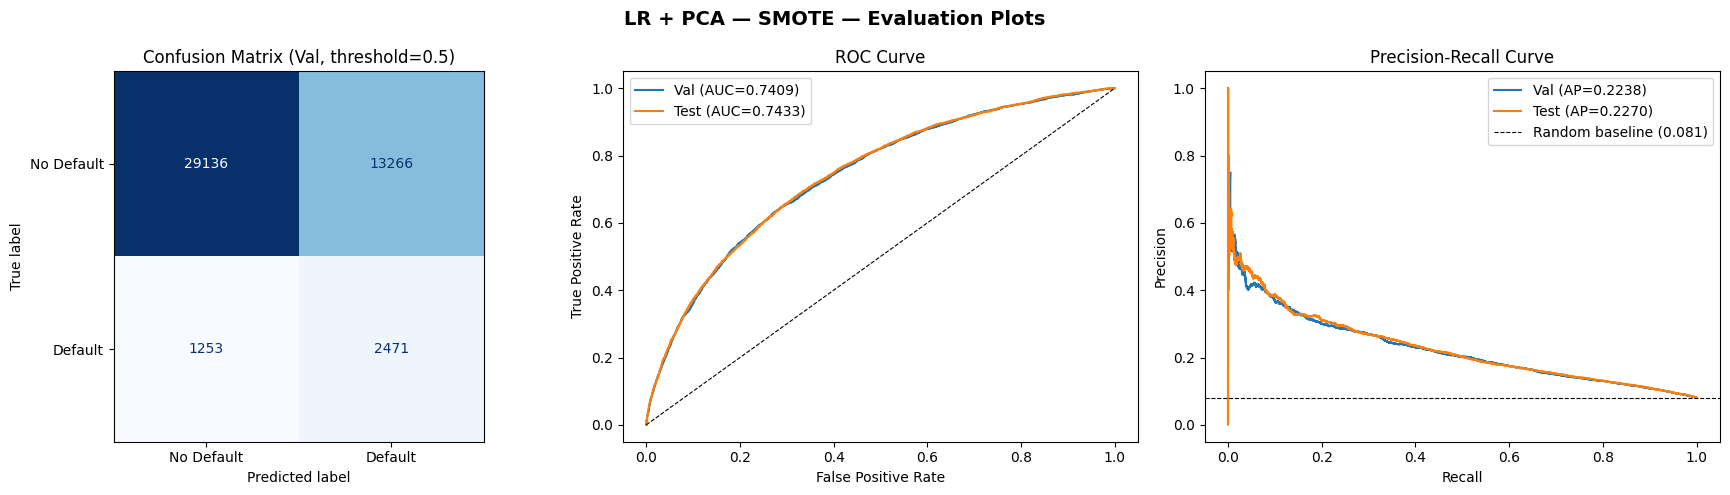

In [7]:
lr_smote = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight=None,
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
)

print("Training LR (SMOTE) on PCA-reduced training set...")
lr_smote.fit(X_train_smote, y_train_smote)
print(f"  Converged in {lr_smote.n_iter_[0]} iterations.")

results_smote_val  = evaluate_model(lr_smote, X_val,  y_val,  split_name="Val  (SMOTE train, PCA)")
results_smote_test = evaluate_model(lr_smote, X_test, y_test, split_name="Test (SMOTE train, PCA)")

plot_evaluation(lr_smote, X_val, y_val, X_test, y_test,
                title_prefix="LR + PCA — SMOTE")

## 6. Model Comparison Summary

=== LR + PCA — Results Summary ===

Training Set                      Split  ROC-AUC   PR-AUC
    Original Val  (original train, PCA) 0.745339 0.223296
    Original Test (original train, PCA) 0.748120 0.231553
       SMOTE    Val  (SMOTE train, PCA) 0.740926 0.223830
       SMOTE    Test (SMOTE train, PCA) 0.743265 0.226989


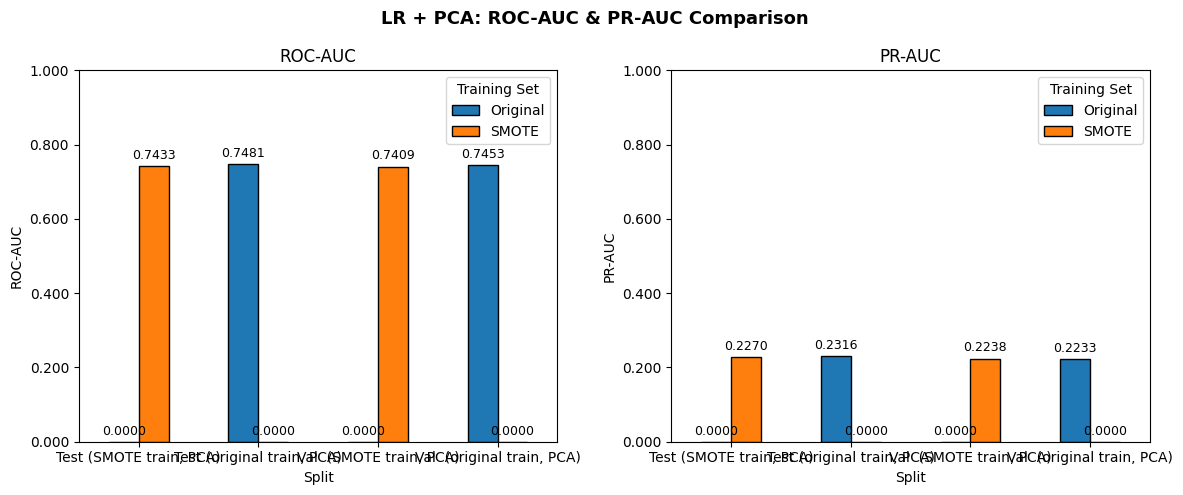

In [8]:
summary = pd.DataFrame([
    results_base_val,
    results_base_test,
    results_smote_val,
    results_smote_test,
])
summary["training_set"] = ["Original", "Original", "SMOTE", "SMOTE"]
summary = summary[["training_set", "split", "roc_auc", "pr_auc"]]
summary.columns = ["Training Set", "Split", "ROC-AUC", "PR-AUC"]

print("=== LR + PCA — Results Summary ===\n")
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LR + PCA: ROC-AUC & PR-AUC Comparison", fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC"]):
    bar_data = summary.pivot(index="Split", columns="Training Set", values=metric)
    bar_data.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)
    ax.legend(title="Training Set")

plt.tight_layout()
plt.show()

## 7. Threshold Analysis (Best Model)

Best model (by val ROC-AUC): class_weight='balanced'

Best F1 threshold on val set : 0.660
  Precision : 0.2298
  Recall    : 0.4057
  F1        : 0.2934


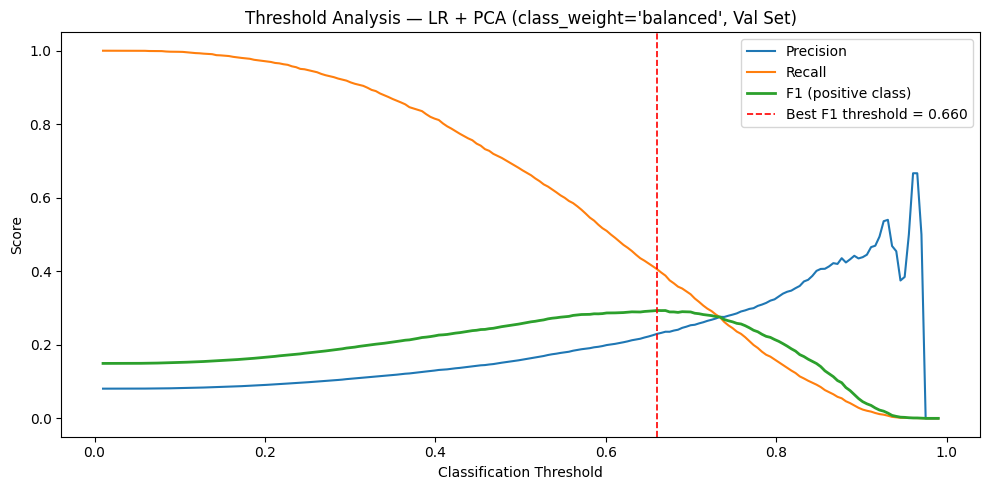


--- Test set evaluation at optimal threshold ---

  Test (threshold=0.660) — threshold = 0.6600502512562815
  ROC-AUC : 0.7481
  PR-AUC  : 0.2316

                precision    recall  f1-score   support

No Default (0)       0.94      0.88      0.91     42402
   Default (1)       0.23      0.42      0.30      3724

      accuracy                           0.84     46126
     macro avg       0.59      0.65      0.60     46126
  weighted avg       0.89      0.84      0.86     46126



In [9]:
best_model = lr_base if results_base_val["roc_auc"] >= results_smote_val["roc_auc"] else lr_smote
best_label = "class_weight='balanced'" if best_model is lr_base else "SMOTE"
print(f"Best model (by val ROC-AUC): {best_label}")

y_prob_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
metrics = []
for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    metrics.append({"threshold": t, "precision": prec, "recall": rec, "f1": f1})

metrics_df = pd.DataFrame(metrics)
best_t_row = metrics_df.loc[metrics_df["f1"].idxmax()]
best_threshold = best_t_row["threshold"]

print(f"\nBest F1 threshold on val set : {best_threshold:.3f}")
print(f"  Precision : {best_t_row['precision']:.4f}")
print(f"  Recall    : {best_t_row['recall']:.4f}")
print(f"  F1        : {best_t_row['f1']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["recall"],    label="Recall",    linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["f1"],        label="F1 (positive class)", linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=1.2,
           label=f"Best F1 threshold = {best_threshold:.3f}")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Analysis — LR + PCA ({best_label}, Val Set)")
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Test set evaluation at optimal threshold ---")
_ = evaluate_model(best_model, X_test, y_test,
                   split_name=f"Test (threshold={best_threshold:.3f})",
                   threshold=best_threshold)

## 8. Feature Importance — Two Views

Since LR coefficients are now in **PC space**, we use two complementary views:

1. **PC-space coefficients** — which principal components the model weighted most, and in which direction.
2. **Back-projected original-feature importance** — weight each original feature by how much it contributes to the high-coefficient PCs. Formula: $w_j = \sum_k |\beta_k| \cdot |v_{kj}|$ where $\beta_k$ is the LR coefficient for PC $k$ and $v_{kj}$ is the loading of original feature $j$ on PC $k$.

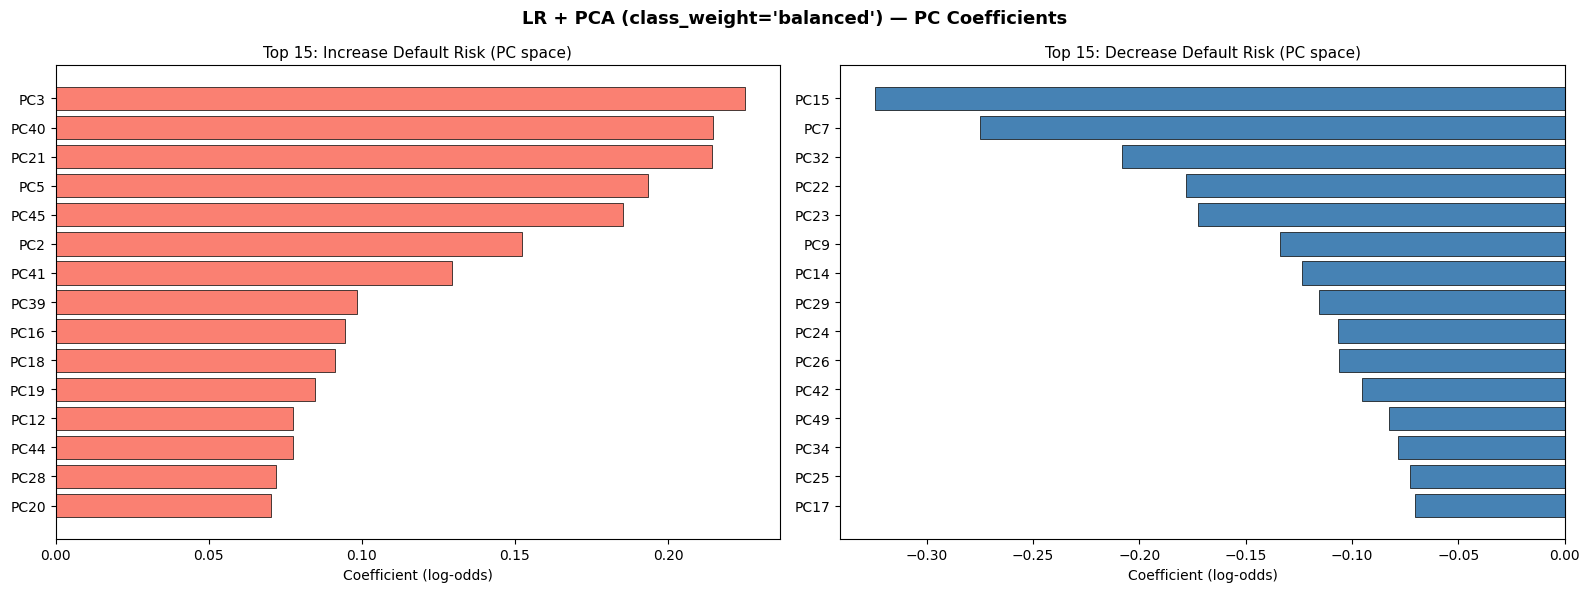

Top 10 PCs by absolute coefficient:
  PC  coefficient  variance_%
PC15    -0.324281    2.183841
 PC7    -0.274863    3.049318
 PC3     0.225294    5.018370
PC40     0.214689    0.548647
PC21     0.214373    1.835325
PC32    -0.208188    1.308343
 PC5     0.193496    4.077736
PC45     0.185358    0.376778
PC22    -0.178140    1.822760
PC23    -0.172534    1.791257


In [10]:
# --- 8.1 PC-space coefficients ---
coef_pc = pd.DataFrame({
    "PC"         : pca_feature_names,
    "coefficient": best_model.coef_[0],
    "variance_%" : pca.explained_variance_ratio_ * 100,
}).sort_values("coefficient", ascending=False)

n_pcs = len(pca_feature_names)
n_show = min(30, n_pcs)
top_half = n_show // 2
top_pos = coef_pc.head(top_half)
top_neg = coef_pc.tail(top_half).sort_values("coefficient")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"LR + PCA ({best_label}) — PC Coefficients",
             fontsize=13, fontweight='bold')

axes[0].barh(top_pos["PC"], top_pos["coefficient"],
             color="salmon", edgecolor="black", linewidth=0.5)
axes[0].set_title(f"Top {top_half}: Increase Default Risk (PC space)", fontsize=11)
axes[0].set_xlabel("Coefficient (log-odds)")
axes[0].invert_yaxis()

axes[1].barh(top_neg["PC"], top_neg["coefficient"],
             color="steelblue", edgecolor="black", linewidth=0.5)
axes[1].set_title(f"Top {top_half}: Decrease Default Risk (PC space)", fontsize=11)
axes[1].set_xlabel("Coefficient (log-odds)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 10 PCs by absolute coefficient:")
coef_pc["abs_coef"] = coef_pc["coefficient"].abs()
print(coef_pc.sort_values("abs_coef", ascending=False)
             .drop(columns="abs_coef")
             .head(10)
             .to_string(index=False))

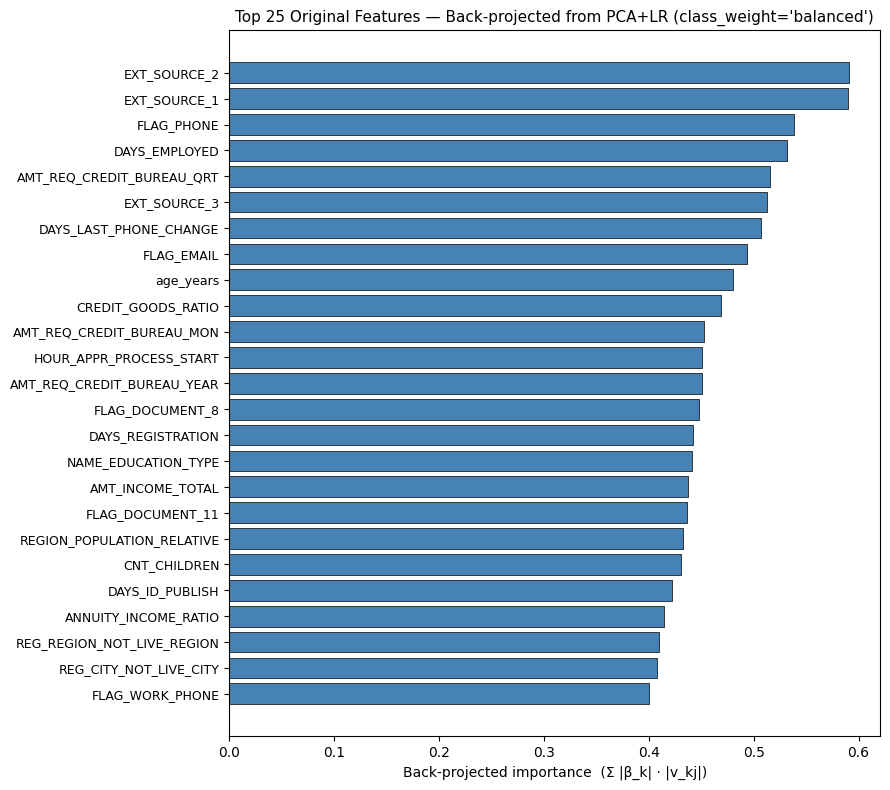


Top 25 original features by back-projected importance:
                   feature  importance
              EXT_SOURCE_2    0.590843
              EXT_SOURCE_1    0.590004
                FLAG_PHONE    0.538208
             DAYS_EMPLOYED    0.531673
 AMT_REQ_CREDIT_BUREAU_QRT    0.515535
              EXT_SOURCE_3    0.512939
    DAYS_LAST_PHONE_CHANGE    0.506634
                FLAG_EMAIL    0.493834
                 age_years    0.480333
        CREDIT_GOODS_RATIO    0.468848
 AMT_REQ_CREDIT_BUREAU_MON    0.452323
   HOUR_APPR_PROCESS_START    0.450842
AMT_REQ_CREDIT_BUREAU_YEAR    0.450309
           FLAG_DOCUMENT_8    0.447730
         DAYS_REGISTRATION    0.442386
       NAME_EDUCATION_TYPE    0.441602
          AMT_INCOME_TOTAL    0.436939
          FLAG_DOCUMENT_11    0.435971
REGION_POPULATION_RELATIVE    0.432692
              CNT_CHILDREN    0.430421
           DAYS_ID_PUBLISH    0.422350
      ANNUITY_INCOME_RATIO    0.414414
REG_REGION_NOT_LIVE_REGION    0.409968
    REG_

In [11]:
# --- 8.2 Back-projection to original feature space ---
# Approximate original-feature importance:
#   importance_j = sum_k ( |beta_k| * |v_kj| )
# This sums the absolute LR weight of each PC, scaled by how much each
# original feature loads onto that PC.

abs_coefs   = np.abs(best_model.coef_[0])           # shape (n_pcs,)
abs_loadings = np.abs(pca.components_)              # shape (n_pcs, n_original_features)

# Weighted sum: (n_pcs,) @ (n_pcs, n_features) → (n_features,)
backprojected = abs_coefs @ abs_loadings

importance_df = pd.DataFrame({
    "feature"   : raw_feature_names,
    "importance": backprojected,
}).sort_values("importance", ascending=False)

N_TOP = 25
top_features = importance_df.head(N_TOP)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_features["feature"][::-1], top_features["importance"][::-1],
        color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Back-projected importance  (Σ |β_k| · |v_kj|)", fontsize=10)
ax.set_title(f"Top {N_TOP} Original Features — Back-projected from PCA+LR ({best_label})",
             fontsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print(f"\nTop {N_TOP} original features by back-projected importance:")
print(importance_df.head(N_TOP).to_string(index=False))

## 9. Compare PCA Model vs Standard LR Baseline

Load the standard (non-PCA) baseline metrics saved by `lr_baseline_model.ipynb` and put
both side by side. This is the key comparison: did PCA hurt, help, or have no effect on AUC?

In [12]:
BASELINE_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models"

try:
    baseline_summary = pd.read_csv(f"{BASELINE_DIR}/lr_baseline_summary.csv")
    baseline_summary.insert(0, "Model", "LR (no PCA)")

    pca_summary = summary.copy()
    pca_summary.insert(0, "Model", "LR + PCA")
    pca_summary.columns = baseline_summary.columns

    comparison = pd.concat([baseline_summary, pca_summary], ignore_index=True)
    print("=== LR Baseline vs LR + PCA ===\n")
    print(comparison.to_string(index=False))

    # Visual comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("LR Baseline vs LR + PCA", fontsize=13, fontweight='bold')

    for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC"]):
        pivot = comparison.pivot_table(
            index="Split", columns="Model", values=metric, aggfunc="mean"
        )
        pivot.plot(kind='bar', ax=ax, rot=15, edgecolor='black')
        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
        for container in ax.containers:
            ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)
        ax.legend(title="Model")

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Note: lr_baseline_summary.csv not found — run lr_baseline_model.ipynb first.")
    print("\nPCA model summary:")
    print(summary.to_string(index=False))

Note: lr_baseline_summary.csv not found — run lr_baseline_model.ipynb first.

PCA model summary:
Training Set                      Split  ROC-AUC   PR-AUC
    Original Val  (original train, PCA) 0.745339 0.223296
    Original Test (original train, PCA) 0.748120 0.231553
       SMOTE    Val  (SMOTE train, PCA) 0.740926 0.223830
       SMOTE    Test (SMOTE train, PCA) 0.743265 0.226989


## 10. Save Results

In [13]:
OUT_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models"
os.makedirs(OUT_DIR, exist_ok=True)

# Save best model
joblib.dump(best_model, f"{OUT_DIR}/lr_pca.pkl")
print(f"Saved model  -> {OUT_DIR}/lr_pca.pkl")

# Save test predictions + probabilities
y_prob_test = best_model.predict_proba(X_test)[:, 1]
preds_df = pd.DataFrame({
    "y_true"    : y_test.values,
    "y_prob"    : y_prob_test,
    "y_pred_05" : (y_prob_test >= 0.5).astype(int),
    "y_pred_opt": (y_prob_test >= best_threshold).astype(int),
})
preds_df.to_csv(f"{OUT_DIR}/lr_pca_test_preds.csv", index=False)
print(f"Saved preds  -> {OUT_DIR}/lr_pca_test_preds.csv")

# Save summary
summary.to_csv(f"{OUT_DIR}/lr_pca_summary.csv", index=False)
print(f"Saved summary-> {OUT_DIR}/lr_pca_summary.csv")

# Save back-projected importances
importance_df.to_csv(f"{OUT_DIR}/lr_pca_feature_importance.csv", index=False)
print(f"Saved importances -> {OUT_DIR}/lr_pca_feature_importance.csv")

# Save PC-space coefficients
coef_pc[["PC", "coefficient", "variance_%"]].to_csv(
    f"{OUT_DIR}/lr_pca_coefficients_pc.csv", index=False
)
print(f"Saved PC coefs    -> {OUT_DIR}/lr_pca_coefficients_pc.csv")

print("\nAll outputs saved successfully.")

Saved model  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_pca.pkl
Saved preds  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_pca_test_preds.csv
Saved summary-> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_pca_summary.csv
Saved importances -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_pca_feature_importance.csv
Saved PC coefs    -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/lr_pca_coefficients_pc.csv

All outputs saved successfully.


## 11. Summary & Takeaways

| Model | Training Set | Val ROC-AUC | Test ROC-AUC | Val PR-AUC | Test PR-AUC |
|---|---|---|---|---|---|
| LR + PCA | Original (class_weight=balanced) | *see results above* | ... | ... | ... |
| LR + PCA | SMOTE | *see results above* | ... | ... | ... |

**Interpreting the PCA vs no-PCA comparison:**
- **AUC ≈ same or slightly lower:** PCA is lossless at 95% variance but the dropped 5% may contain
  discriminative signal. A small AUC dip (e.g. 0.005) is expected and acceptable.
- **AUC notably lower:** The discarded components contained structured signal — try 99% threshold.
- **AUC higher:** PCA regularised the model by removing noisy/collinear dimensions — this is the
  ideal outcome for Logistic Regression on correlated tabular data.

**Coefficient interpretation in PC space:**
- PC coefficients are not directly interpretable in original feature terms.
- Use the back-projected importance (Section 8.2) to identify which original features drive predictions.
- EXT_SOURCE_1/2/3 should still dominate — consistent with the non-PCA baseline.

**Next steps:**
- `04_random_forest.ipynb` — PCA less critical for trees but can still be compared
- `05_mlp.ipynb` — PCA often most beneficial here (reduces input width, speeds up training)
- `06_elastic_net.ipynb` — PCA + Elastic Net is interesting because EN already does feature selection